1. 데이터를 불러오고 확인한다.
2. 입력데이터 x와 정답데이터 y로 데이터를 나눈다.
3. 학습용 데이터와 테스트용 데이터로 데이터를 분리한다.
4. 모델을 학습하고, 학습된 모델로 예측을 해본다.
5. 중간에 필요할 때 시각화한다.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


# sklearn = 머신러닝 데이터셋,모델,함수,평가 도구 등
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split # 학습, 테스트 데이터 분리용
from sklearn.tree import DecisionTreeClassifier, plot_tree # 의사결정나무분류모델, 의사결정그리기도구
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay # 정확도, 검증 지표, 혼동행렬 표시기
plt.rcParams["font.family"] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False


In [2]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
X= iris.data
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [4]:
y = iris.target
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
iris.feature_names   # 데이터 컬럼명 확인

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
iris.target_names   # 타겟데이터 이름 확인

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [7]:
df = pd.DataFrame(X,columns=iris.feature_names)
df['target'] = y
df['target_name'] = df['target'].map(lambda i: iris.target_names[i])

df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


- sepal length : 꽃바침 길이
- sepal width : 꽃받침 너비
- petal length : 꽃잎 길이
- petal width  : 꽃잎 너비

In [8]:
print(df.shape)
print(iris.target_names)

(150, 6)
['setosa' 'versicolor' 'virginica']


In [9]:
target_counts  = df['target_name'].value_counts().sort_index()  # 품종별 갯수 확인
target_counts

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

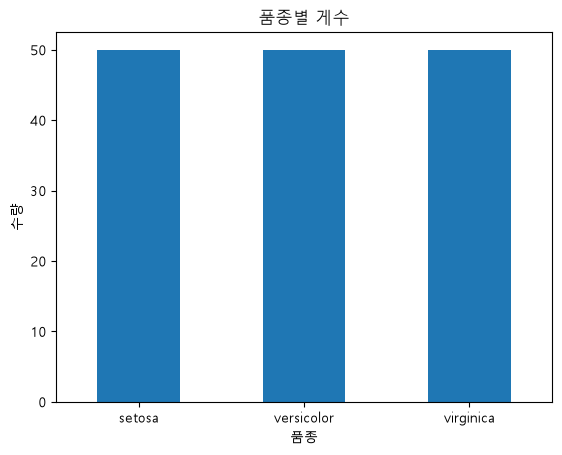

In [10]:
plt.Figure(figsize=(6,4))
target_counts.plot(kind='bar')
plt.title("품종별 게수")
plt.xlabel('품종')
plt.ylabel('수량')
plt.xticks(rotation = 0)
plt.show()

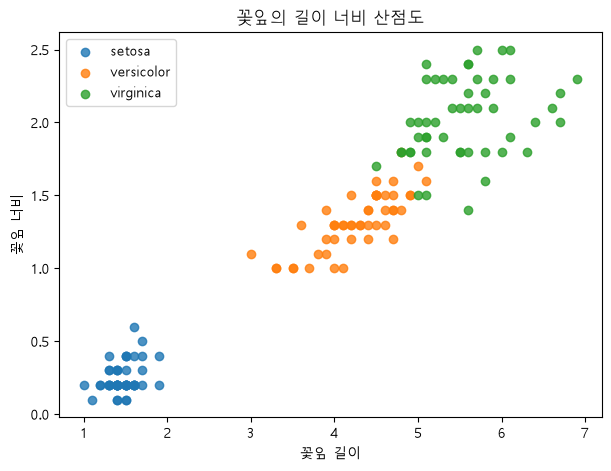

In [11]:
plt.figure(figsize=(7,5))

for species in iris.target_names:
    subset = df[df['target_name']==species]

    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label = species,
        alpha= 0.8
    )
plt.title("꽃잎의 길이 너비 산점도")
plt.xlabel('꽃잎 길이')
plt.ylabel('꽃잎 너비')
plt.legend()
plt.show()

In [12]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [13]:
X = df[iris.feature_names]  # 모델이 보고 학습할 문제 데이터
y = df['target']            # 모델이 맞혀야 할 정답 데이터


print('X 크기 :',X.shape)
print('y 크기 :',y.shape)


X 크기 : (150, 4)
y 크기 : (150,)


In [14]:
# 학습용 데이터와 테스트 데이터를 8:2 비율로 분리


X_train, X_test, y_train, y_test,  = train_test_split(
    X,
    y,
    test_size= 0.2,   # 전체중 20%는 테스트데이터
    random_state= 42,
    stratify= y          # 품종 비율을 비슷하게 유지
)
print(f"학습용 X : {X_train.shape}")
print(f"테스트 X : {X_test.shape}")

학습용 X : (120, 4)
테스트 X : (30, 4)


In [15]:
# 모델 생성 및 학습


model = DecisionTreeClassifier(
    max_depth=3,        # 의사결정 깊이
    random_state= 42
)

model.fit(X_train,y_train)   # 모델 학습

print('모델 학습 완료!')

모델 학습 완료!


In [16]:
# 학습이 끝난 모델에 테스트 데이터를 넣고 예측 결과 확인

y_pred = model.predict(X_test)

y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])

In [17]:
y_test

38     0
127    2
57     1
93     1
42     0
56     1
22     0
20     0
147    2
84     1
107    2
141    2
104    2
51     1
7      0
49     0
14     0
69     1
63     1
138    2
10     0
140    2
58     1
134    2
132    2
77     1
75     1
18     0
116    2
28     0
Name: target, dtype: int64

In [18]:
accuracy = accuracy_score(y_test,y_pred)

print(f"정확도 : {accuracy*100:.2f}%")

정확도 : 96.67%


In [19]:
report = classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names,
    output_dict=True
)
# report # 딕셔너리
pd.DataFrame(report).T  # 레포트를 데이터 프레임형식으로 출력 (전치: 인덱스<-> 컬럼)

,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,10.000000
versicolor,1.000000,0.900000,0.947368,10.000000
virginica,0.909091,1.000000,0.952381,10.000000
accuracy,0.966667,0.966667,0.966667,0.966667
macro avg,0.969697,0.966667,0.966583,30.000000
weighted avg,0.969697,0.966667,0.966583,30.000000


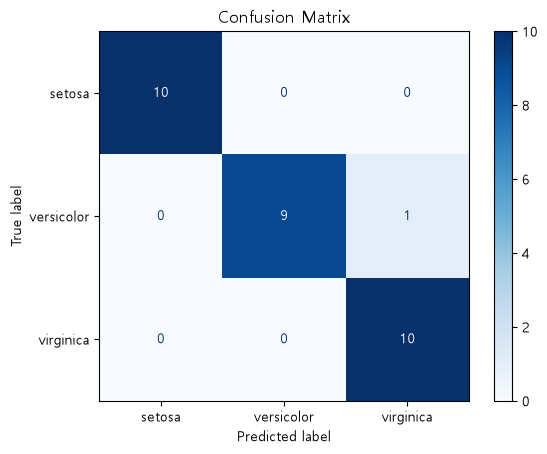

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names,
    cmap = 'Blues'
)

plt.title("Confusion Matrix")
plt.show()

In [21]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [22]:
# 추론용 샘플데이터 생성

sample = pd.DataFrame(
    [[5.1, 3.0, 1.4, 1.0]],
    columns= iris.feature_names
)
sample

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.0,1.4,1.0


In [23]:
pred = model.predict(sample)            # 샘플 데이터로 예측
pred_name = iris.target_names[pred[0]]  # 품종 이름으로 변환
pred_name

np.str_('setosa')

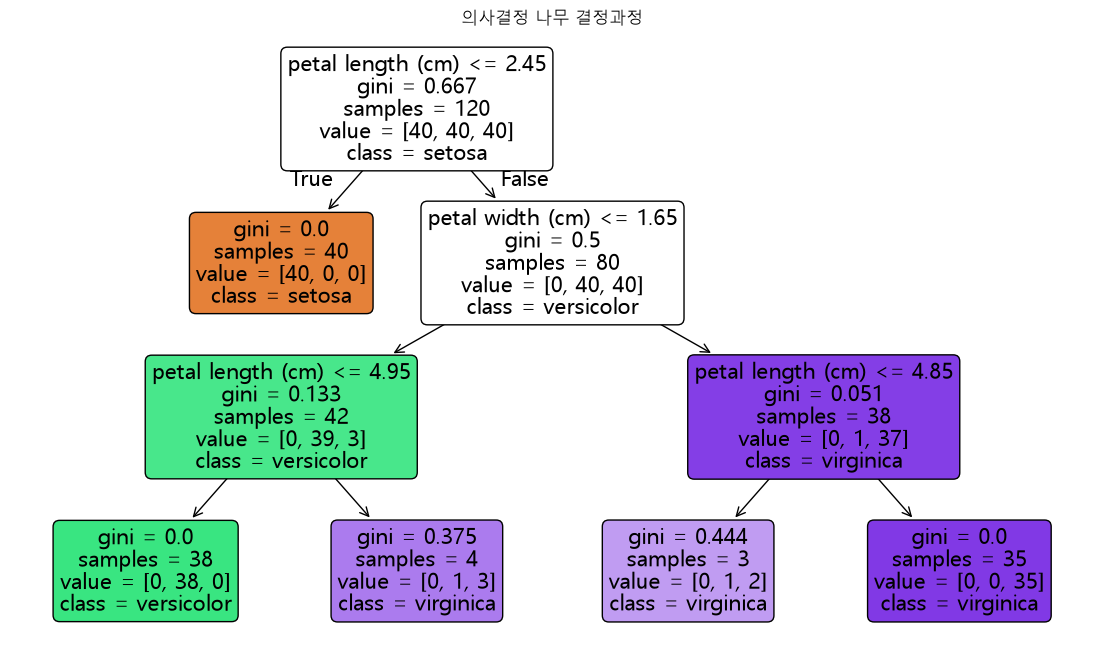

In [24]:
# 모델이 학습한 규칙 확인 (의사결정나무)

plt.figure(figsize=(14,8))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names= iris.target_names,
    filled= True,
    rounded = True
)
plt.title("의사결정 나무 결정과정")
plt.show()

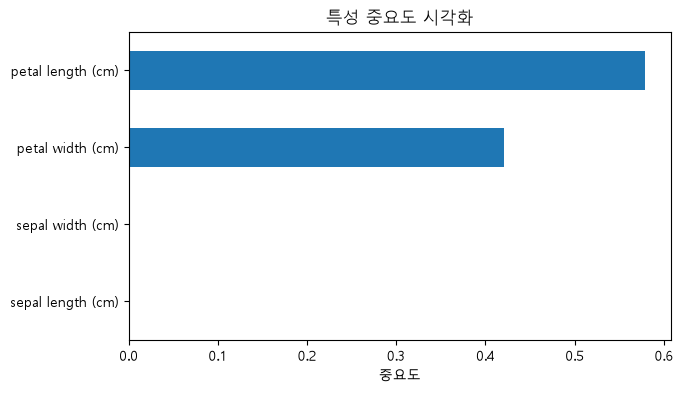

In [25]:
# 중요도 판단 : 어떤 특성이 결정에 영향을 미쳤는지

importance = pd.Series(
    model.feature_importances_,
    index = iris.feature_names
).sort_values()
plt.figure(figsize=(7,4))
importance.plot(kind='barh')
plt.title('특성 중요도 시각화')
plt.xlabel('중요도')
plt.show()

## 머신러닝 순서
- 1. 데이터 준비

- 2. 데이터 전처리

- 3. 입력데이터 x, 정답데이터 y 분리

- 4. 학습용 데이터와 테스트용 데이터 분리

- 5. 모델 생성

- 6. fit() 모델 학습

- 7. 테스트 데이터로 검증

- 8. predict() 예측

- 9. 모델 정확도 시각화